예제 8.1 오토 인코더

In [ ]:
# 예제 8.1 오토 인코더

#셋업
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
(x_train, _), (x_test, _) = mnist.load_data()

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
# 데이터 정규화
x_train = x_train / 255.
x_test = x_test / 255.

In [ ]:
# 오토 인코더 정의
class AutoEncoder(Model):
    def __init__(self, latent_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = Sequential([   # 인코더
            Flatten(input_shape=(28, 28)),
            Dense(latent_dim, activation='relu')
        ])

        self.decoder = Sequential([   # 디코더
            Dense(28 * 28, activation='sigmoid'),
            Reshape((28, 28))
        ])

    def call(self, inputs):
        x = self.encoder(inputs)
        x = self.decoder(x)
        return x

# 모델 생성
model = AutoEncoder(latent_dim=32)

In [ ]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse')

In [ ]:
# 모델 학습
history = model.fit(x_train, x_train, batch_size=32, epochs=10, verbose=0)

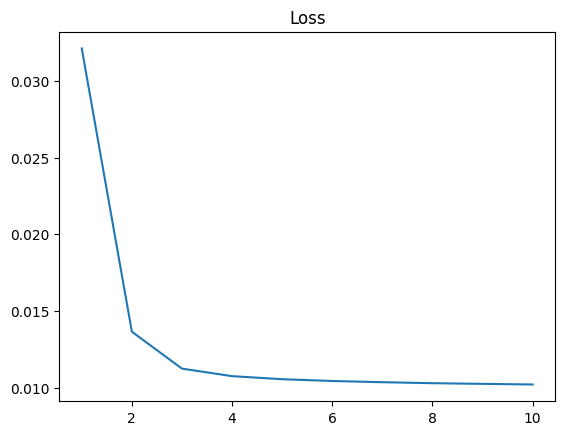

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, len(history.history['loss']) + 1),
        history.history['loss'])
plt.title('Loss')

plt.show()

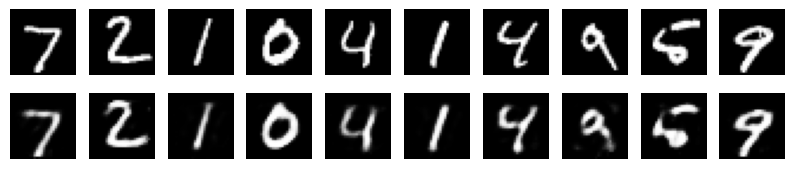

In [ ]:
# 원본 이미지/재구성 이미지 시각화
plt.figure(figsize=(10, 2))

for i in range(10):

    # 원본 이미지
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')

    # 재구성 이미지
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(model(x_test)[i], cmap='gray')
    plt.axis('off')

plt.show()